# ASNR Graph Classification
Classifying animal social networks by interaction type and biological class using GNNs.


## Data Loading

In [2]:
from pathlib import Path
import networkx as nx
import pandas as pd

folder_path = Path('./asnr datasets')
assert folder_path.exists() #if crashing here, fix your filepath / working directory

asnr_graphs = {}
for file_path in folder_path.glob('*.graphml'):
    graph = nx.read_graphml(file_path)
    asnr_graphs[file_path.stem + '.graphml'] = graph

info_frame = pd.read_csv(folder_path / 'Network_summary_masterfile.csv')


In [3]:
print(f'Loaded {len(asnr_graphs)} graphs')
print("Column Names:")
print(info_frame.columns.tolist())

Loaded 1197 graphs
Column Names:
['Network_ID', 'Network_Identifiers', 'class', 'genus', 'species', 'interaction_type', 'definition_of_interaction', 'edge_wt_type', 'geographical_location', 'population_type', 'data_record_technique', 'time_span', 'resolution', 'time_span_per_day', 'attributes_available', 'is_connected', 'num_components', 'nodes', 'edges', 'network.density', 'highest.degree', 'avg.degree', 'std.degree.node', 'CV.degree', 'skewness', 'avg.node.strength', 'std.node.strength', 'CV.node.strength', 'avg.edge.strength', 'std.edge.strength', 'CV.edge.strength', 'highest.node.strength', 'deg.assort', 'avg.betw.centrality', 'std.betw.centrality', 'highest.betw', 'avg.betw.centrality.weighted', 'std.betw.centrality.weighted', 'highest.betw.weighted', 'clustering', 'clustering.weighted', 'transitivity', 'Q', 'Qmax', 'Qrel', 'cohesion', 'num.modules', 'avg.modsize', 'diameter', 'Citation']


### Filter Data

In [4]:
#Graph visualisations per interaction type
selected_interactions = [
    'physical_contact',
    'social_projection_bipartite',
    'spatial_proximity',
    'grooming',
    'dominance',
    'FE_mating',
]

selected_classes = [
    'Mammalia',
    'Insecta',
    'Aves'
]

filtered_df = info_frame[
    info_frame['interaction_type'].isin(selected_interactions) &
    info_frame['class'].isin(selected_classes) &
    (info_frame['nodes'] > 5) &
    pd.notna(info_frame['avg.edge.strength']) #Filter out graphs with no edges
].copy().rename(columns={'class': 'network_class'})

interaction_mapping = {c: i for i, c in enumerate(selected_interactions)}
filtered_df['interaction_map'] = filtered_df['interaction_type'].map(interaction_mapping)

print('Filtered dataset size:', len(filtered_df))
print(filtered_df['interaction_type'].value_counts())
print(len(filtered_df[filtered_df['network_class'] == 'Mammalia']['species'].value_counts()))

Filtered dataset size: 924
interaction_type
social_projection_bipartite    288
physical_contact               270
spatial_proximity              153
grooming                       115
dominance                       50
FE_mating                       48
Name: count, dtype: int64
53


## Dataset Construction

In [5]:
import torch
from torch_geometric.data import Data

# Biological class label mapping (stored alongside interaction label)
bio_class_mapping = {c: i for i, c in enumerate(filtered_df['network_class'].unique())}
print('Biological class mapping:', bio_class_mapping)
print('Interaction type mapping:', interaction_mapping)

def build_dataset(graphs_dict, df_subset):
    """
    Build a list of PyG Data objects.
    Each Data object stores:
      x            — node features: [degree, local_clustering_coeff]
      edge_index   — COO edge list
      interaction_type            — interaction type label (classification target)
      bio_class    — biological class label (for analysis)
      network_id   — string identifier
    """
    dataset = []
    for _, row in df_subset.iterrows():
        key = row['Network_ID']
        if key not in graphs_dict:
            continue
        graph = graphs_dict[key]
        G_und = graph.to_undirected() if graph.is_directed() else graph

        # Now we enumerate nodes (to get edge index)
        node_mapping = {node: i for i, node in enumerate(G_und.nodes())}

        # Node features: degree + local clustering coefficient
        clustering = nx.clustering(G_und)
        x = torch.tensor(
            [[G_und.degree(node), clustering[node]] for node in G_und.nodes()],
            dtype=torch.float
        )

        # Edge index (undirected — add both directions)
        edges = []
        for u, v in G_und.edges():
            edges.append([node_mapping[u], node_mapping[v]])
            edges.append([node_mapping[v], node_mapping[u]])
        if len(edges) == 0:
            continue  # skip edgeless graphs
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

        interaction_type = torch.tensor([row['interaction_map']], dtype=torch.long)
        bio_label = torch.tensor([bio_class_mapping.get(row['network_class'], -1)], dtype=torch.long)

        data = Data(x=x, edge_index=edge_index, y=interaction_type)
        data.bio_class = bio_label
        data.network_id = key
        dataset.append(data)

    return dataset


Biological class mapping: {'Insecta': 0, 'Mammalia': 1, 'Aves': 2}
Interaction type mapping: {'physical_contact': 0, 'social_projection_bipartite': 1, 'spatial_proximity': 2, 'grooming': 3, 'dominance': 4, 'FE_mating': 5}


## Train / Val / Test Split (Stratified)

In [6]:
from sklearn.model_selection import train_test_split

# First split off test set (15%), then split remainder into train (70%) and val (15%)
train_val_df, test_df = train_test_split(
    filtered_df,
    test_size=0.15,
    stratify=filtered_df['interaction_map'],
    random_state=42,
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.15 / 0.85,  # ~15% of total
    stratify=train_val_df['interaction_map'],
    random_state=42,
)

"""print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')
print('Train interaction counts:')
print(train_df['interaction_type'].value_counts())
print(train_df['Network_class'].value_counts())"""

train_dataset = build_dataset(asnr_graphs, train_df)
val_dataset   = build_dataset(asnr_graphs, val_df)
test_dataset  = build_dataset(asnr_graphs, test_df)

print(f'\nBuilt {len(train_dataset)} train / {len(val_dataset)} val / {len(test_dataset)} test graphs')

Train: 646  Val: 139  Test: 139
Train interaction counts:
interaction_type
social_projection_bipartite    202
physical_contact               188
spatial_proximity              107
grooming                        81
FE_mating                       34
dominance                       34
Name: count, dtype: int64

Built 646 train / 139 val / 139 test graphs


In [7]:
print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')
print('Train class counts:')
print(train_df['network_class'].value_counts())
print(val_df['network_class'].value_counts())
print(test_df['network_class'].value_counts())

Train: 646  Val: 139  Test: 139
Train class counts:
network_class
Mammalia    361
Insecta     193
Aves         92
Name: count, dtype: int64
network_class
Mammalia    78
Insecta     37
Aves        24
Name: count, dtype: int64
network_class
Mammalia    77
Insecta     38
Aves        24
Name: count, dtype: int64


## Data Augmentation

In [9]:
import copy
import random

def augment_graph_node_drop(data, drop_prob=0.05):
    #Return none if too small
    data_aug = copy.deepcopy(data)
    num_nodes = data_aug.num_nodes
    if num_nodes <= 5:
        return None

    keep_mask = torch.tensor(
        [random.random() > drop_prob for _ in range(num_nodes)],
        dtype=torch.bool
    )
    if keep_mask.sum() < 5:
        return None

    # Filter node features
    data_aug.x = data_aug.x[keep_mask]

    # Filter edges: keep only edges where both endpoints survive
    edge_index = data_aug.edge_index
    edge_mask = keep_mask[edge_index[0]] & keep_mask[edge_index[1]]
    edge_index = edge_index[:, edge_mask]

    # Reindex nodes to be contiguous
    old_to_new = torch.full((num_nodes,), -1, dtype=torch.long)
    old_to_new[keep_mask] = torch.arange(keep_mask.sum())
    data_aug.edge_index = old_to_new[edge_index]

    return data_aug

"""
We generally have large class imbalances, so we want to oversample the minority to try and get the balance back

We also do weighted CE loss to help with this later
"""

def oversample_minority(dataset, df, target_col='interaction_map',
                        copies_per_minority=3, drop_prob=0.05, seed=124):
    """
    Augment training set by generating extra copies of minority class graphs.
    Majority class is left as-is; minority classes get `copies_per_minority`
    augmented copies added.
    """
    random.seed(seed)
    torch.manual_seed(seed)

    counts = df[target_col].value_counts()
    majority_count = counts.max()
    augmented = list(dataset)

    for data in dataset:
        label = data.y.item()
        if counts[label] < (majority_count * 5):
            for _ in range(copies_per_minority):
                aug = augment_graph_node_drop(data, drop_prob=drop_prob)
                if aug is not None:
                    augmented.append(aug)

    return augmented

#If we just want to add a lot of data, we can oversample everything

def oversample_all(dataset, df, target_col='interaction_map',
                        copies_per_minority=20, drop_prob=0.05, seed=124):
    """
    Augment training set by generating extra copies of minority class graphs.
    Majority class is left as-is; minority classes get `copies_per_minority`
    augmented copies added.
    """
    random.seed(seed)
    torch.manual_seed(seed)

    counts = df[target_col].value_counts()
    majority_count = counts.max()
    augmented = list(dataset)

    for data in dataset:
        label = data.y.item()
        #Want to increase lowest class by 5 times, others add 
        if counts[label] < (majority_count * 5):
            for _ in range(copies_per_minority):
                aug = augment_graph_node_drop(data, drop_prob=drop_prob)
                if aug is not None:
                    augmented.append(aug)
                    counts[label] += 1

    return augmented



In [10]:
augmented_train = oversample_all(
    train_dataset, train_df,
    copies_per_minority=20,
    drop_prob=0.08,
    target_col = 'interaction_map'
)

from collections import Counter

print(f'Train before augmentation: {len(train_dataset)}')
print(f'Train after augmentation (interaction):  {len(augmented_train)}')

print('Biological class mapping:', bio_class_mapping)
print('Interaction type mapping:', interaction_mapping)

print('Augmented (interaction) interaction counts:')
interaction_counts = Counter(sample['y'].item() for sample in augmented_train)
print(interaction_counts)

print('Augmented (interaction) class counts:')
network_counts = Counter(sample['bio_class'].item() for sample in augmented_train)
print(network_counts)

Train before augmentation: 646
Train after augmentation (interaction):  5507
Biological class mapping: {'Insecta': 0, 'Mammalia': 1, 'Aves': 2}
Interaction type mapping: {'physical_contact': 0, 'social_projection_bipartite': 1, 'spatial_proximity': 2, 'grooming': 3, 'dominance': 4, 'FE_mating': 5}
Augmented (interaction) interaction counts:
Counter({0: 1025, 2: 1024, 3: 1021, 1: 1020, 5: 714, 4: 703})
Augmented (interaction) class counts:
Counter({1: 2915, 2: 1439, 0: 1153})


In [11]:
import pandas as pd

rows = []

for sample in augmented_train:
    rows.append({
        'bio_class': sample['bio_class'].item(),
        'interaction_type': sample['y'].item()
    })

df_counts = pd.DataFrame(rows)

cross_tab = pd.crosstab(
    df_counts['bio_class'],
    df_counts['interaction_type']
)


bio_inv = {v: k for k, v in bio_class_mapping.items()}
interaction_inv = {v: k for k, v in interaction_mapping.items()}

cross_tab.index = [bio_inv[i] for i in cross_tab.index]
cross_tab.columns = [interaction_inv[i] for i in cross_tab.columns]

print('\nBio class × Interaction type')
print(cross_tab)


Bio class × Interaction type
          physical_contact  social_projection_bipartite  spatial_proximity  \
Insecta                893                            0                 50   
Mammalia                24                          781                824   
Aves                   108                          239                150   

          grooming  dominance  FE_mating  
Insecta          0          0        210  
Mammalia       830        309        147  
Aves           191        394        357  


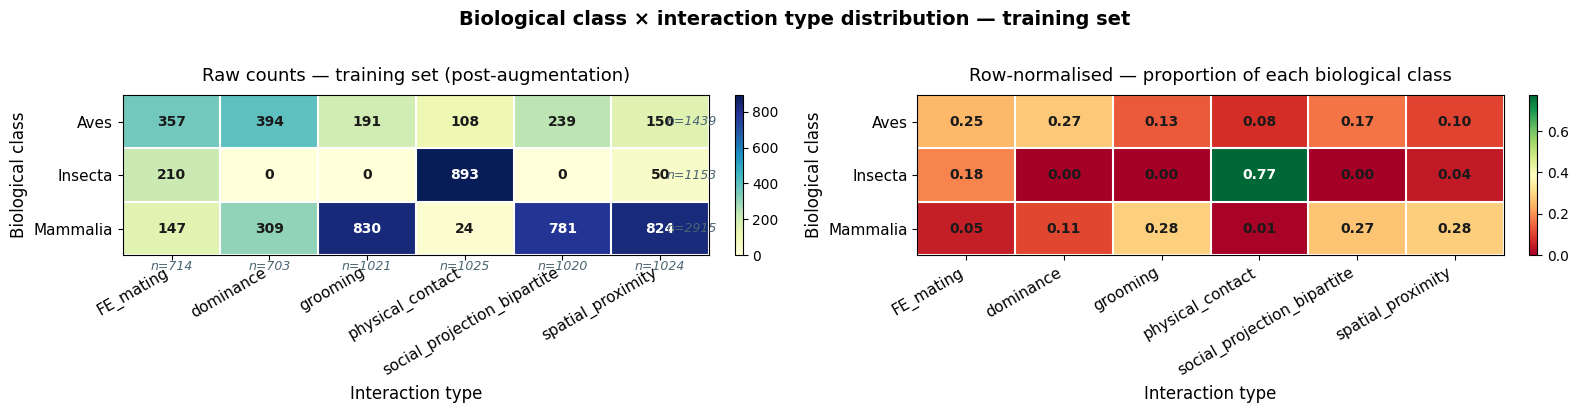


Raw counts:
interaction_type  FE_mating  dominance  grooming  physical_contact  social_projection_bipartite  spatial_proximity
bio_class                                                                                                         
Aves                    357        394       191               108                          239                150
Insecta                 210          0         0               893                            0                 50
Mammalia                147        309       830                24                          781                824

Row-normalised:
interaction_type  FE_mating  dominance  grooming  physical_contact  social_projection_bipartite  spatial_proximity
bio_class                                                                                                         
Aves                  0.248      0.274     0.133             0.075                        0.166              0.104
Insecta               0.182      0.000     0.000  

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Build the cross-tabulation ────────────────────────────────────────────────
rows = []
for sample in augmented_train:
    rows.append({
        'bio_class':        bio_inv[sample['bio_class'].item()],
        'interaction_type': interaction_inv[sample['y'].item()]
    })

df_counts  = pd.DataFrame(rows)
cross_tab  = pd.crosstab(df_counts['bio_class'], df_counts['interaction_type'])

# Row-normalised version (shows proportions within each bio class)
cross_norm = cross_tab.div(cross_tab.sum(axis=1), axis=0)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, data, fmt, title, cmap in zip(
    axes,
    [cross_tab,  cross_norm],
    ['d',        '.2f'],
    ['Raw counts — training set (post-augmentation)',
     'Row-normalised — proportion of each biological class'],
    ['YlGnBu',   'RdYlGn'],
):
    im = ax.imshow(data.values, cmap=cmap, aspect='auto',
                   vmin=0, vmax=data.values.max())

    # Axis labels
    ax.set_xticks(range(len(data.columns)))
    ax.set_yticks(range(len(data.index)))
    ax.set_xticklabels(data.columns, rotation=30, ha='right', fontsize=11)
    ax.set_yticklabels(data.index, fontsize=11)
    ax.set_xlabel('Interaction type', fontsize=12)
    ax.set_ylabel('Biological class', fontsize=12)
    ax.set_title(title, fontsize=13, pad=10)

    # Gridlines between cells
    ax.set_xticks(np.arange(-0.5, len(data.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(data.index),   1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1.5)
    ax.tick_params(which='minor', bottom=False, left=False)

    # Cell annotations
    vmax = data.values.max()
    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            val = data.values[i, j]
            # White text on dark cells, dark text on light cells
            text_color = 'white' if val > 0.55 * vmax else '#1a1a1a'
            ax.text(j, i, format(val, fmt),
                    ha='center', va='center',
                    fontsize=10, color=text_color, fontweight='bold')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Column totals annotation below raw counts plot
totals = cross_tab.sum(axis=0)
for j, (col, total) in enumerate(totals.items()):
    axes[0].text(j, len(cross_tab) - 0.42, f'n={total}',
                 ha='center', va='top', fontsize=9,
                 color='#4A6572', style='italic')

# Row totals annotation to the right of raw counts plot
row_totals = cross_tab.sum(axis=1)
for i, (row, total) in enumerate(row_totals.items()):
    axes[0].text(len(cross_tab.columns) - 0.42, i, f'n={total}',
                 ha='right', va='center', fontsize=9,
                 color='#4A6572', style='italic')

plt.suptitle('Biological class × interaction type distribution — training set',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_distribution_heatmap.pdf', bbox_inches='tight')
plt.show()

# ── Also print the table for reference ───────────────────────────────────────
print('\nRaw counts:')
print(cross_tab.to_string())
print('\nRow-normalised:')
print(cross_norm.round(3).to_string())

## Model Definition

In [ ]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(augmented_train, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32)
test_loader  = DataLoader(test_dataset,  batch_size=32)

In [ ]:
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import GCNConv, global_mean_pool


class GCNClassifier(nn.Module):
    """
    3-layer GCN with global mean pooling and an MLP classification head.
    Input node features: [degree, local_clustering_coeff] → in_channels=2
    """
    def __init__(self, in_channels=2, hidden_dim=64, num_classes=6, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.dropout = dropout
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def encode(self, x, edge_index, batch):
        """Return graph-level embeddings (before classification head)."""
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv3(x, edge_index))
        return global_mean_pool(x, batch)

    def forward(self, data):
        emb = self.encode(data.x, data.edge_index, data.batch)
        return self.classifier(emb)

## Training - Interaction

In [ ]:
from sklearn.metrics import f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Weighted cross-entropy: weight_c = total / (n_classes * count_c)
# NOTE: Change samples here to fix CE weighting (y - interaction type, bio_class - class)
vc = Counter(sample['y'].item() for sample in augmented_train)
class_counts = torch.tensor([vc.get(i, 1) for i in range(len(selected_interactions))], dtype=torch.float)
weights = class_counts.sum() / (len(class_counts) * class_counts)
print('Class weights:', weights.numpy().round(3))

model = GCNClassifier(in_channels=2, hidden_dim=64, num_classes=len(selected_interactions)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=weights.to(device))
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for data in loader:
            data = data.to(device)
            if train:
                optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, data.y)
            if train:
                loss.backward()
                optimizer.step()
            preds = out.argmax(dim=1)
            total_loss += loss.item() * data.num_graphs
            correct += (preds == data.y).sum().item()
            total += data.num_graphs
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(data.y.cpu().tolist())

    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, correct / total, macro_f1


best_val_f1 = 0.0
best_model_state = None
history = []

for epoch in range(1, 81):
    tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, train=True)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, train=False)
    scheduler.step()

    history.append({
        'epoch': epoch,
        'tr_loss': tr_loss, 'tr_acc': tr_acc, 'tr_f1': tr_f1,
        'val_loss': val_loss, 'val_acc': val_acc, 'val_f1': val_f1,
    })

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = copy.deepcopy(model.state_dict())

    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d} | '
              f'Train loss {tr_loss:.4f} acc {tr_acc:.3f} F1 {tr_f1:.3f} | '
              f'Val loss {val_loss:.4f} acc {val_acc:.3f} F1 {val_f1:.3f}')

# Restore best model
model.load_state_dict(best_model_state)
print(f'\nBest val macro F1: {best_val_f1:.4f}')

Using device: cpu
Class weights: [0.895 0.9   0.896 0.899 1.306 1.285]
Epoch 010 | Train loss 0.9680 acc 0.608 F1 0.597 | Val loss 1.0193 acc 0.662 F1 0.565
Epoch 020 | Train loss 0.8742 acc 0.647 F1 0.637 | Val loss 1.1142 acc 0.655 F1 0.565
Epoch 030 | Train loss 0.8167 acc 0.669 F1 0.660 | Val loss 1.0907 acc 0.669 F1 0.578
Epoch 040 | Train loss 0.7923 acc 0.676 F1 0.668 | Val loss 1.0472 acc 0.683 F1 0.585
Epoch 050 | Train loss 0.7673 acc 0.683 F1 0.677 | Val loss 1.0518 acc 0.676 F1 0.589
Epoch 060 | Train loss 0.7460 acc 0.689 F1 0.683 | Val loss 1.0986 acc 0.669 F1 0.584
Epoch 070 | Train loss 0.7310 acc 0.695 F1 0.690 | Val loss 1.0775 acc 0.647 F1 0.561
Epoch 080 | Train loss 0.7218 acc 0.705 F1 0.701 | Val loss 1.0864 acc 0.669 F1 0.593

Best val macro F1: 0.6098


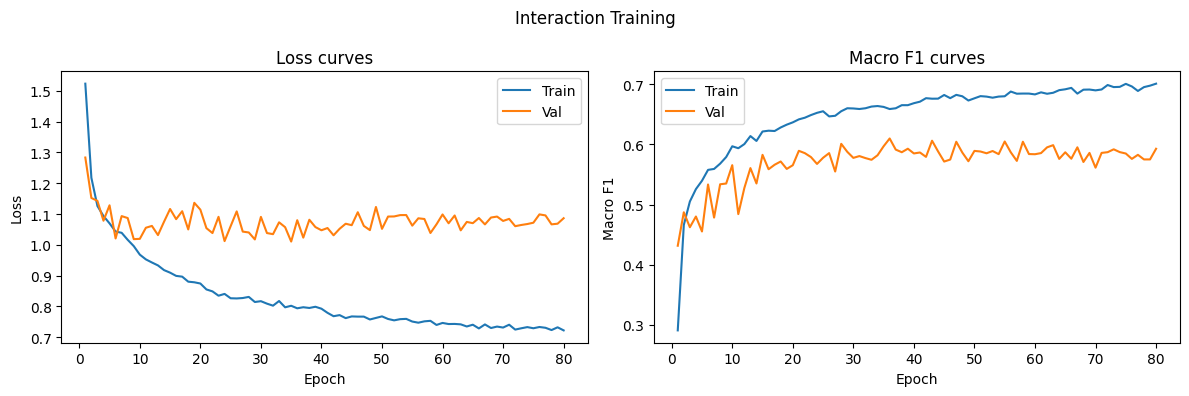

In [ ]:
# Training Curves
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df['epoch'], hist_df['tr_loss'], label='Train')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss curves')
axes[0].legend()

axes[1].plot(hist_df['epoch'], hist_df['tr_f1'], label='Train')
axes[1].plot(hist_df['epoch'], hist_df['val_f1'], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Macro F1 curves')
axes[1].legend()

plt.suptitle("Interaction Training")
plt.tight_layout()
plt.savefig('interaction_training_curves.pdf', bbox_inches='tight')
plt.show()

In [ ]:
train_loader = DataLoader(augmented_train, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32)
test_loader  = DataLoader(test_dataset,  batch_size=32)

In [ ]:
from sklearn.metrics import f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Weighted cross-entropy: weight_c = total / (n_classes * count_c)
# NOTE: Change samples here to fix CE weighting (y - interaction type, bio_class - class)
bio_vc = Counter(sample['bio_class'].item() for sample in augmented_train)
bio_class_counts = torch.tensor([bio_vc.get(i, 1) for i in range(len(selected_classes))], dtype=torch.float)
bio_weights = bio_class_counts.sum() / (len(bio_class_counts) * bio_class_counts)

bio_model = GCNClassifier(in_channels=2, hidden_dim=64, num_classes=len(selected_classes)).to(device)
optimizer = torch.optim.Adam(bio_model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=bio_weights.to(device))
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)


def bio_run_epoch(loader, train=True):
    bio_model.train() if train else bio_model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for data in loader:
            data = data.to(device)
            if train:
                optimizer.zero_grad()
            out = bio_model(data)
            loss = criterion(out, data.bio_class)
            if train:
                loss.backward()
                optimizer.step()
            preds = out.argmax(dim=1)
            total_loss += loss.item() * data.num_graphs
            correct += (preds == data.bio_class).sum().item()
            total += data.num_graphs
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(data.bio_class.cpu().tolist())

    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, correct / total, macro_f1


bio_best_val_f1 = 0.0
bio_best_model_state = None
bio_history = []

for epoch in range(1, 41):
    bio_tr_loss, bio_tr_acc, bio_tr_f1 = bio_run_epoch(train_loader, train=True)
    bio_val_loss, bio_val_acc, bio_val_f1 = bio_run_epoch(val_loader, train=False)
    scheduler.step()

    bio_history.append({
        'epoch': epoch,
        'tr_loss': bio_tr_loss, 'tr_acc': bio_tr_acc, 'tr_f1': bio_tr_f1,
        'val_loss': bio_val_loss, 'val_acc': bio_val_acc, 'val_f1': bio_val_f1,
    })

    if bio_val_f1 > bio_best_val_f1:
        bio_best_val_f1 = val_f1
        bio_best_model_state = copy.deepcopy(bio_model.state_dict())

    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d} | '
              f'Train loss {bio_tr_loss:.4f} acc {bio_tr_acc:.3f} F1 {bio_tr_f1:.3f} | '
              f'Val loss {bio_val_loss:.4f} acc {bio_val_acc:.3f} F1 {bio_val_f1:.3f}')

# Restore best model
bio_model.load_state_dict(bio_best_model_state)
print(f'\nBest val macro F1: {bio_best_val_f1:.4f}')

Using device: cpu
Epoch 010 | Train loss 0.5254 acc 0.743 F1 0.739 | Val loss 0.5166 acc 0.755 F1 0.725
Epoch 020 | Train loss 0.4741 acc 0.773 F1 0.771 | Val loss 0.5210 acc 0.784 F1 0.740
Epoch 030 | Train loss 0.4545 acc 0.783 F1 0.783 | Val loss 0.5077 acc 0.777 F1 0.740
Epoch 040 | Train loss 0.4349 acc 0.793 F1 0.792 | Val loss 0.5318 acc 0.777 F1 0.740

Best val macro F1: 0.5927


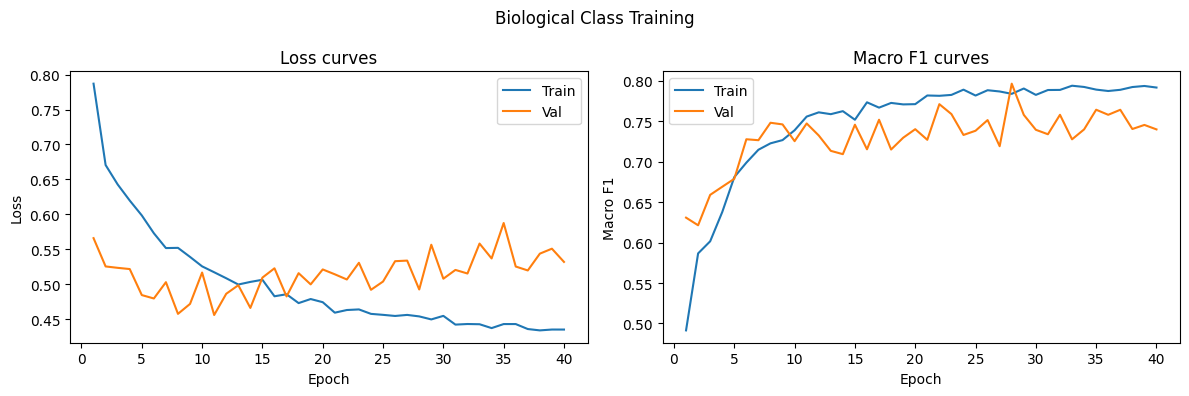

In [ ]:
# Training Curves
bio_hist_df = pd.DataFrame(bio_history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(bio_hist_df['epoch'], bio_hist_df['tr_loss'], label='Train')
axes[0].plot(bio_hist_df['epoch'], bio_hist_df['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss curves')
axes[0].legend()

axes[1].plot(bio_hist_df['epoch'], bio_hist_df['tr_f1'], label='Train')
axes[1].plot(bio_hist_df['epoch'], bio_hist_df['val_f1'], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Macro F1 curves')
axes[1].legend()

plt.suptitle("Biological Class Training")
plt.tight_layout()
plt.savefig('bio_training_curves.pdf', bbox_inches='tight')
plt.show()

## Final Evaluation on Test Set

#### After hyperparams

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def evaluate_model(model, loader, device):
    model.eval()
    all_preds, all_labels, all_bio = [], [], []
    all_network_ids = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            preds = out.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(data.y.cpu().tolist())
            all_bio.extend(data.bio_class.cpu().tolist())
            all_network_ids.extend(data.network_id)

    return (
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_bio),
        all_network_ids,
    )


y_pred, y_true, y_bio, net_ids = evaluate_model(model, test_loader, device)

print('=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=selected_interactions, zero_division=0))

=== Classification Report ===
                             precision    recall  f1-score   support

           physical_contact       0.89      0.98      0.93        41
social_projection_bipartite       0.72      0.65      0.68        43
          spatial_proximity       0.43      0.26      0.32        23
                   grooming       0.45      0.53      0.49        17
                  dominance       0.38      0.38      0.38         8
                  FE_mating       0.54      1.00      0.70         7

                   accuracy                           0.67       139
                  macro avg       0.57      0.63      0.58       139
               weighted avg       0.66      0.67      0.66       139



In [ ]:
y_pred, y_true, y_bio, net_ids = evaluate_model(bio_model, test_loader, device)


print('=== Classification Report ===')
print(classification_report(y_bio, y_pred, target_names=bio_names, zero_division=0))

=== Classification Report ===
              precision    recall  f1-score   support

     Insecta       0.88      1.00      0.94        38
    Mammalia       0.92      0.73      0.81        77
        Aves       0.54      0.79      0.64        24

    accuracy                           0.81       139
   macro avg       0.78      0.84      0.80       139
weighted avg       0.84      0.81      0.82       139



## Confusion Matrix

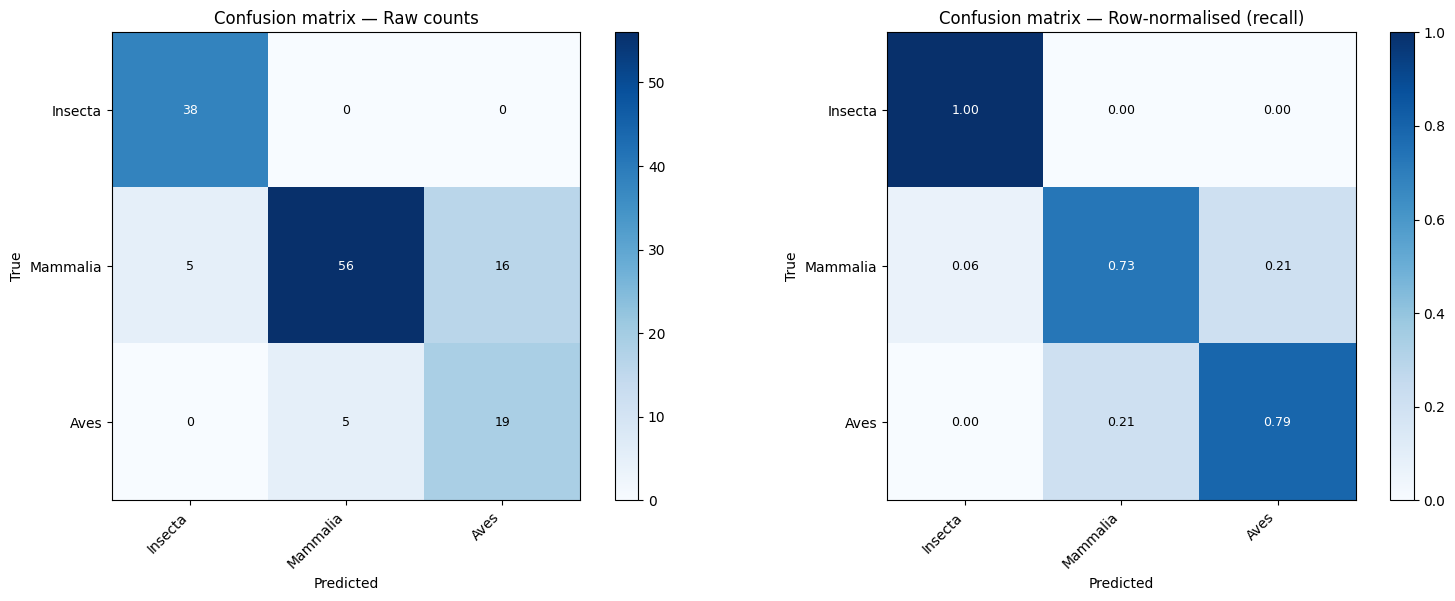

[1 1 2 2 0 1 2 2 1 0 0 0 1 1 0 1 1 0 0 1 1 1 1 2 2 0 1 1 1 1 1 1 0 0 1 1 0
 1 0 1 2 0 1 1 0 1 2 1 1 0 2 1 2 1 1 1 1 0 1 2 1 1 2 0 1 1 0 2 1 0 1 1 1 0
 1 1 2 2 1 1 1 1 1 2 1 1 2 2 0 0 2 1 0 0 1 2 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 0 0 2 1 1 0 1 1 1 0 0 1 0 2 1 0 0 2 2 1 0 1 0 1 1 1]
[1 2 2 2 0 1 2 2 1 0 0 0 2 2 0 1 2 0 0 2 1 1 1 2 1 0 1 0 1 1 1 1 0 0 1 1 0
 1 0 1 2 0 1 0 0 0 2 1 1 0 2 1 2 1 1 1 1 0 1 2 1 1 2 0 1 1 0 2 2 0 1 1 1 0
 1 2 1 1 0 1 2 1 2 2 1 1 1 2 0 0 2 1 0 0 1 2 1 1 1 0 0 2 1 1 1 0 1 1 0 2 1
 0 2 0 0 2 1 1 0 2 2 1 0 0 2 0 2 2 0 0 2 1 1 0 1 0 1 1 1]


In [ ]:

def plot_confusion_matrix(y_true, y_pred, class_names, title='Confusion matrix', filename=None):
    cm = confusion_matrix(y_true, y_pred)
    # Normalise rows to show recall per class
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, data, fmt, subtitle in zip(
        axes, [cm,cm_norm], ['d', '.2f'], ['Raw counts', 'Row-normalised (recall)']
    ):
        im = ax.imshow(data, cmap='Blues')
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right')
        ax.set_yticklabels(class_names)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title(f'{title} — {subtitle}')
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                ax.text(j, i, format(data[i, j], fmt),
                        ha='center', va='center',
                        color='white' if data[i, j] > data.max() * 0.6 else 'black',
                        fontsize=9)
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    if filename:
        plt.savefig(filename, bbox_inches='tight')
    plt.show()
    return cm


cm = plot_confusion_matrix(y_bio, y_pred, bio_names,
                           filename='confusion_matrix.pdf')
print(y_bio)
print(y_pred)

## Biological Analysis
Cross-tabulate prediction accuracy by biological class and interaction type.

In [ ]:
# Build a results DataFrame for the test set
bio_class_inv = {v: k for k, v in bio_class_mapping.items()}
interaction_inv = {v: k for k, v in interaction_mapping.items()}

results_df = pd.DataFrame({
    'network_id': net_ids,
    'true_interaction': [interaction_inv[i] for i in y_true],
    'pred_interaction': [interaction_inv[i] for i in y_pred],
    'bio_class': [bio_class_inv.get(i, 'Unknown') for i in y_bio],
    'correct': y_pred == y_true,
})

print('Accuracy by biological class:')
print(results_df.groupby('bio_class')['correct'].agg(['sum', 'count', 'mean']).rename(
    columns={'sum': 'correct', 'count': 'total', 'mean': 'accuracy'}
))

Accuracy by biological class:
           correct  total  accuracy
bio_class                          
Aves             6     24  0.250000
Insecta         36     38  0.947368
Mammalia        37     77  0.480519


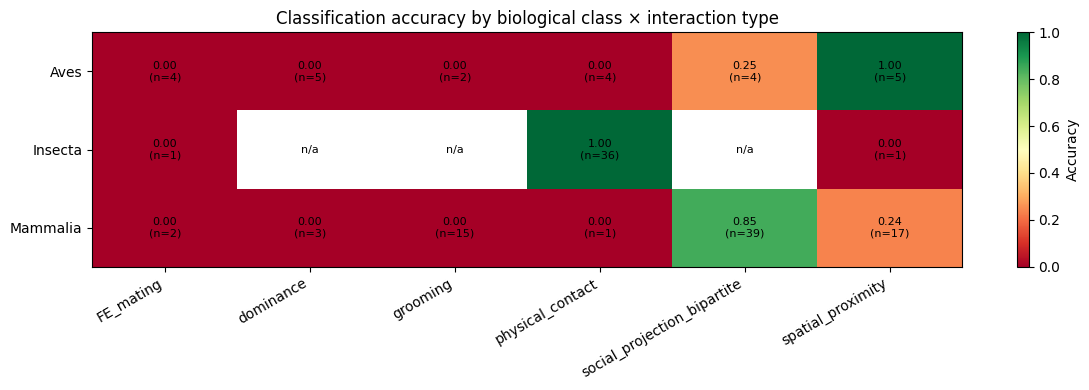

In [ ]:
# --- Heatmap: accuracy per (biological class x interaction type) ---
acc_pivot = results_df.pivot_table(
    index='bio_class',
    columns='true_interaction',
    values='correct',
    aggfunc='mean'
)

count_pivot = results_df.pivot_table(
    index='bio_class',
    columns='true_interaction',
    values='correct',
    aggfunc='count'
)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(acc_pivot.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(acc_pivot.columns)))
ax.set_yticks(range(len(acc_pivot.index)))
ax.set_xticklabels(acc_pivot.columns, rotation=30, ha='right')
ax.set_yticklabels(acc_pivot.index)
ax.set_title('Classification accuracy by biological class × interaction type')

for i in range(len(acc_pivot.index)):
    for j in range(len(acc_pivot.columns)):
        val = acc_pivot.values[i, j]
        n = count_pivot.values[i, j] if not np.isnan(count_pivot.values[i, j]) else 0
        label = f'{val:.2f}\n(n={int(n)})' if not np.isnan(val) else 'n/a'
        ax.text(j, i, label, ha='center', va='center', fontsize=8)

plt.colorbar(im, ax=ax, label='Accuracy')
plt.tight_layout()
plt.savefig('bio_class_accuracy_heatmap.pdf', bbox_inches='tight')
plt.show()

In [ ]:
results_with_feats = results_df.merge(
    feat_df[['Network_ID', 'mean_degree', 'density', 'avg_clustering', 'avg_path_length']],
    left_on='network_id', right_on='Network_ID', how='left'
)

print('Structural features — correctly classified vs misclassified:')
print(results_with_feats.groupby('correct')[['mean_degree', 'density', 'avg_clustering']].median())

Structural features — correctly classified vs misclassified:
         mean_degree   density  avg_clustering
correct                                       
False       5.035714  0.348077        0.545749
True       10.705882  0.634941        0.769675


## Embedding Visualisation

In [ ]:
# Extract graph-level embeddings from the test set
model.eval()
embeddings, labels, bio_labels = [], [], []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        emb = bio_model.encode(data.x, data.edge_index, data.batch)
        embeddings.append(emb.cpu().numpy())
        labels.append(data.y.cpu().numpy())
        bio_labels.append(data.bio_class.cpu().numpy())

embeddings = np.concatenate(embeddings)
labels = np.concatenate(labels)
bio_labels = np.concatenate(bio_labels)

In [ ]:
print(bio_labels)

[1 1 2 2 0 1 2 2 1 0 0 0 1 1 0 1 1 0 0 1 1 1 1 2 2 0 1 1 1 1 1 1 0 0 1 1 0
 1 0 1 2 0 1 1 0 1 2 1 1 0 2 1 2 1 1 1 1 0 1 2 1 1 2 0 1 1 0 2 1 0 1 1 1 0
 1 1 2 2 1 1 1 1 1 2 1 1 2 2 0 0 2 1 0 0 1 2 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 0 0 2 1 1 0 1 1 1 0 0 1 0 2 1 0 0 2 2 1 0 1 0 1 1 1]


C:\Users\BetterOffBread\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


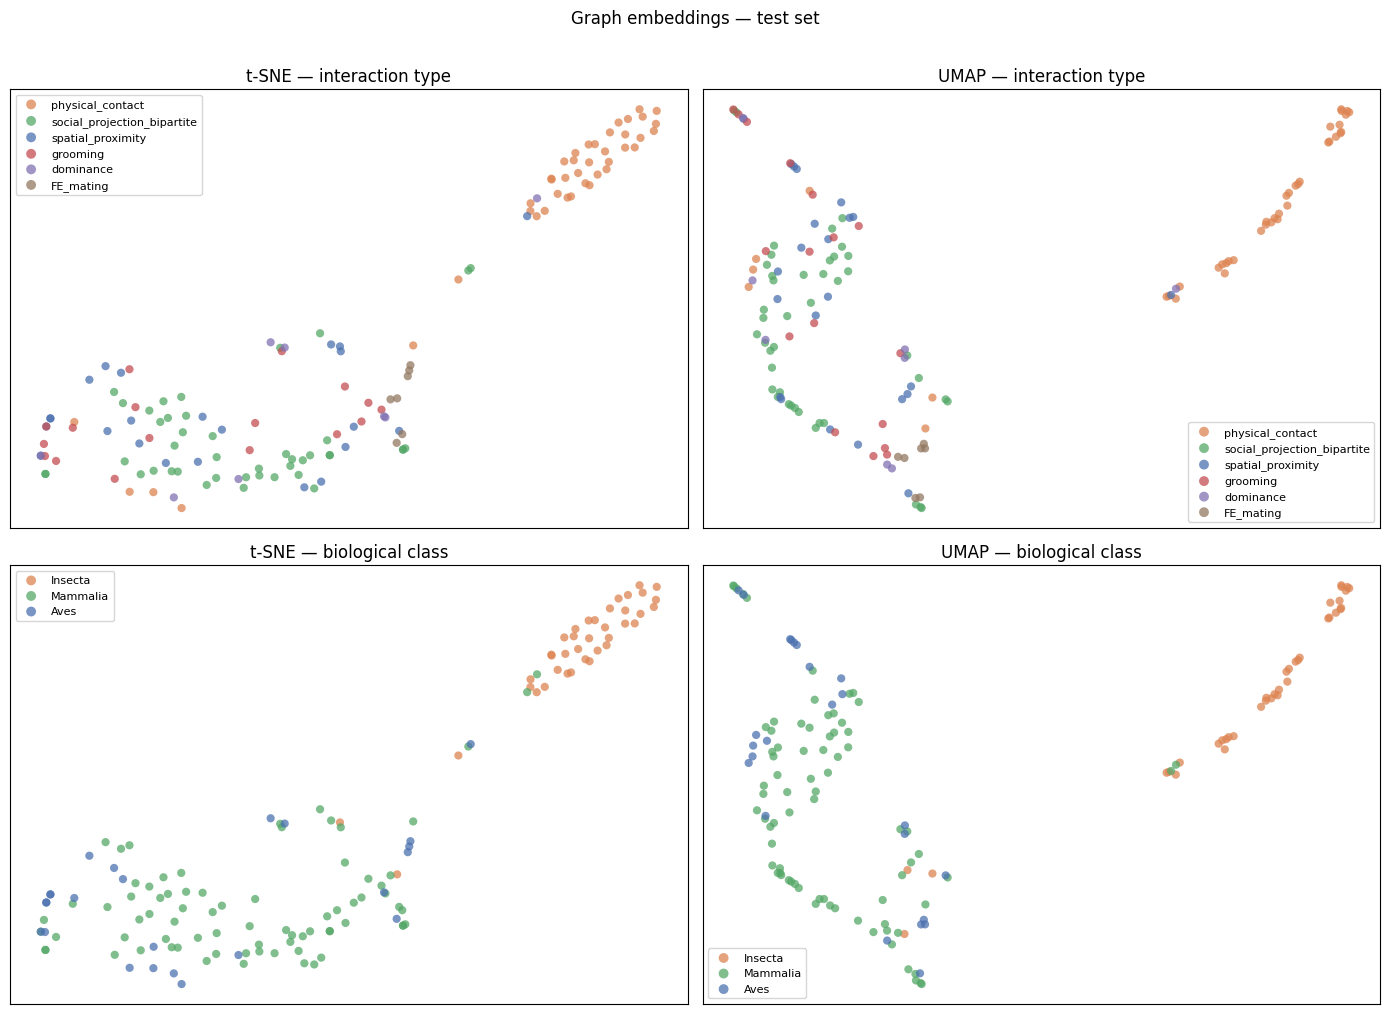

In [ ]:
from sklearn.manifold import TSNE


import umap
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
coords_umap = reducer.fit_transform(embeddings)



coords_tsne = TSNE(n_components=2, perplexity=min(30, len(embeddings) - 1),
                   random_state=42).fit_transform(embeddings)


def scatter_embeddings(coords, color_labels, color_names, title, ax, markers=None):
    palette = ['#DD8452', '#55A868', '#4C72B0', '#C44E52', '#8172B2', '#937860']
    for i, name in enumerate(color_names):
        mask = color_labels == i
        marker = markers[i] if markers else 'o'
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   label=name, color=palette[i % len(palette)],
                   alpha=0.75, s=35, marker=marker, edgecolors='none')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(fontsize=8, markerscale=1.2)


n_plots = 2 
fig, axes = plt.subplots(2, n_plots, figsize=(7 * n_plots, 10))
if n_plots == 1:
    axes = axes.reshape(-1, 1)

bio_names = [bio_class_inv[i] for i in sorted(bio_class_inv)]
int_names = selected_interactions

# Row 0: coloured by interaction type
scatter_embeddings(coords_tsne, labels, int_names, 't-SNE — interaction type', axes[0, 0])

scatter_embeddings(coords_umap, labels, int_names, 'UMAP — interaction type', axes[0, 1])

# Row 1: coloured by biological class
scatter_embeddings(coords_tsne, bio_labels, bio_names, 't-SNE — biological class', axes[1, 0])
scatter_embeddings(coords_umap, bio_labels, bio_names, 'UMAP — biological class', axes[1, 1])

plt.suptitle('Graph embeddings — test set', y=1.01)
plt.tight_layout()
plt.savefig('embeddings.pdf', bbox_inches='tight')
plt.show()

In [ ]:
print(bio_names)
print(selected_classes)

['Insecta', 'Mammalia', 'Aves']
['Mammalia', 'Insecta', 'Aves']


### NOTE NOT ACTUAL CATEGORY BOUNDARIES

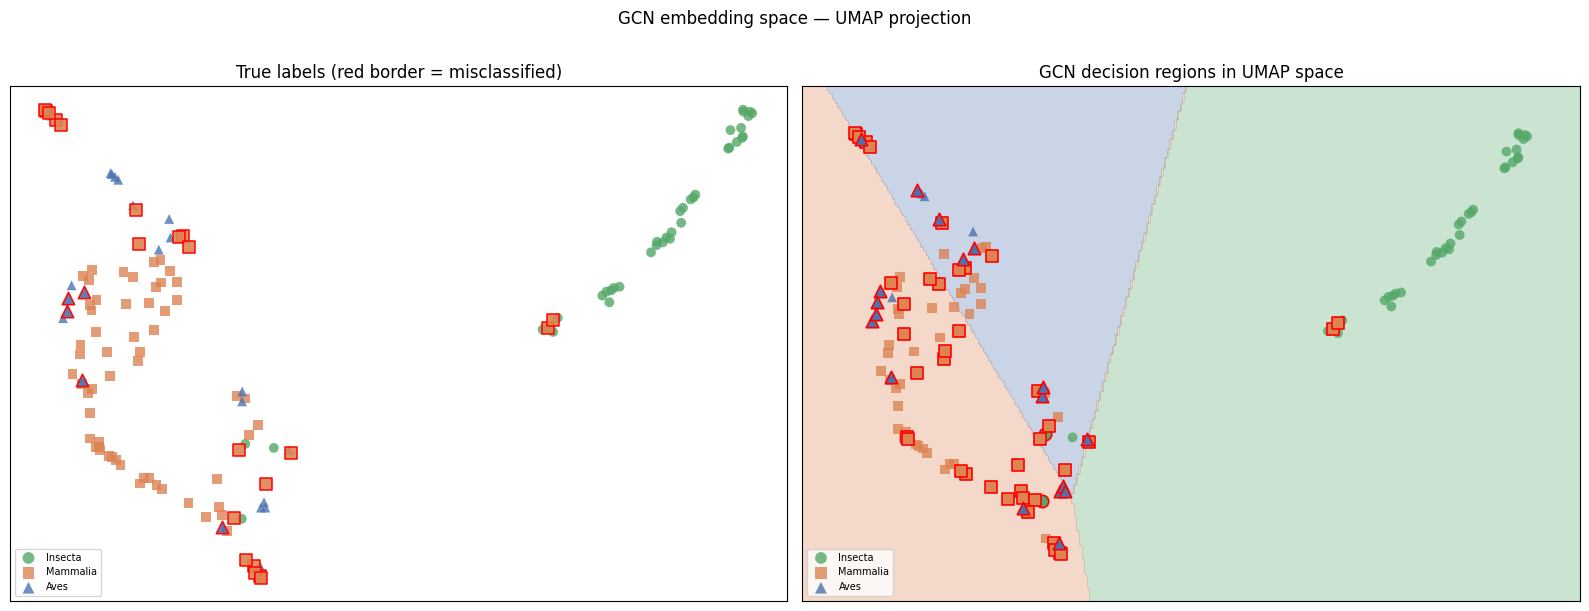

In [ ]:
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

# Assumes coords_umap, labels (true), y_pred, selected_interactions already exist

palette = ['#55A868', '#DD8452','#4C72B0', '#C44E52', '#8172B2', '#937860']
markers = ['o', 's', '^', 'D', 'v', 'P']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: true vs predicted, misclassified highlighted ---
ax = axes[0]
correct_mask = y_pred == bio_labels

for i, name in enumerate(bio_names):
    mask = (bio_labels == i) & correct_mask
    ax.scatter(coords_umap[mask, 0], coords_umap[mask, 1],
               color=palette[i], marker=markers[i],
               alpha=0.8, s=50, label=name, edgecolors='none')

# Misclassified: show true class colour, red border
for i, name in enumerate(bio_names):
    mask = (bio_labels == i) & ~correct_mask
    ax.scatter(coords_umap[mask, 0], coords_umap[mask, 1],
               color=palette[i], marker=markers[i],
               alpha=0.9, s=80, edgecolors='red', linewidths=1.2)

ax.set_title('True labels (red border = misclassified)')
ax.set_xticks([]); ax.set_yticks([])
ax.legend(fontsize=7, markerscale=1.2)

# --- Plot 2: decision regions in UMAP space ---
ax = axes[1]

# Fit logistic regression in 2D UMAP space
clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(coords_umap, y_pred)  # fit on predicted labels = GCN's view of the world

# Create a meshgrid covering the UMAP space
x_min, x_max = coords_umap[:, 0].min() - 1, coords_umap[:, 0].max() + 1
y_min, y_max = coords_umap[:, 1].min() - 1, coords_umap[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Shade background by decision region
cmap_bg = ListedColormap([c + '40' for c in palette[:len(bio_names)]])
ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg,
            levels=np.arange(-0.5, len(bio_names)))

# Overlay actual points coloured by true label
for i, name in enumerate(bio_names):
    mask = bio_labels == i
    ax.scatter(coords_umap[mask, 0], coords_umap[mask, 1],
               color=palette[i], marker=markers[i],
               alpha=0.8, s=50, label=name, edgecolors='none')

# Red borders on misclassified
for i in range(len(bio_names)):
    mask = (bio_labels == i) & (y_pred != labels)
    ax.scatter(coords_umap[mask, 0], coords_umap[mask, 1],
               color=palette[i], marker=markers[i],
               s=80, edgecolors='red', linewidths=1.2)

ax.set_title("GCN decision regions in UMAP space")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(fontsize=7, markerscale=1.2)

plt.suptitle('GCN embedding space — UMAP projection', y=1.01)
plt.tight_layout()
plt.savefig('umap_decision_regions.pdf', bbox_inches='tight')
plt.show()

## Not quite Standard Kernel Implementation

In [ ]:
from collections import Counter
from sklearn.svm import SVC
from sklearn.metrics import f1_score
import networkx as nx
import numpy as np

def wl_relabel(G, node_labels, n_iter=3):
    """
    Run n_iter rounds of WL relabelling on a NetworkX graph.
    Returns a feature vector: histogram of labels across all rounds.
    """
    labels = dict(node_labels)  # copy
    all_label_counts = Counter()

    for _ in range(n_iter):
        new_labels = {}
        for node in G.nodes():
            neighbor_labels = sorted(labels[nbr] for nbr in G.neighbors(node))
            new_labels[node] = hash((labels[node], tuple(neighbor_labels)))
        labels = new_labels
        all_label_counts.update(labels.values())

    return all_label_counts


def graphs_to_wl_features(nx_graphs, label_dicts, n_iter=3):
    """
    Convert a list of NetworkX graphs to WL histogram feature vectors.
    Returns a (n_graphs, n_features) numpy array.
    """
    # First pass: collect all possible labels across the corpus
    histograms = []
    for G, node_labels in zip(nx_graphs, label_dicts):
        hist = wl_relabel(G, node_labels, n_iter=n_iter)
        histograms.append(hist)

    # Build a unified vocabulary of all labels seen
    all_keys = sorted(set(k for h in histograms for k in h.keys()))
    key_index = {k: i for i, k in enumerate(all_keys)}

    # Second pass: convert histograms to fixed-length vectors
    X = np.zeros((len(histograms), len(all_keys)))
    for i, hist in enumerate(histograms):
        for key, count in hist.items():
            if key in key_index:
                X[i, key_index[key]] = count

    return X


def dataset_to_nx(dataset):
    """Convert PyG Data objects back to NetworkX + degree label dicts."""
    nx_graphs, label_dicts = [], []
    for data in dataset:
        G = nx.Graph()
        n = data.num_nodes
        G.add_nodes_from(range(n))
        edges = data.edge_index.t().numpy()
        G.add_edges_from(edges)

        # Use discretised degree as initial node label
        degrees = data.x[:, 0].numpy().astype(int)
        node_labels = {i: int(degrees[i]) for i in range(n)}

        nx_graphs.append(G)
        label_dicts.append(node_labels)

    return nx_graphs, label_dicts


# Build feature matrices
train_nx, train_labels_nx = dataset_to_nx(train_dataset)
val_nx,   val_labels_nx   = dataset_to_nx(val_dataset)
test_nx,  test_labels_nx  = dataset_to_nx(test_dataset)

train_y = [d.y.item() for d in train_dataset]
val_y   = [d.y.item() for d in val_dataset]
test_y  = [d.y.item() for d in test_dataset]

# Tune n_iter and C on validation set
best_f1, best_params = 0.0, {}

for n_iter in [1, 2, 3]:
    X_train = graphs_to_wl_features(train_nx, train_labels_nx, n_iter=n_iter)
    X_val   = graphs_to_wl_features(val_nx,   val_labels_nx,   n_iter=n_iter)

    for C in [0.01, 0.1, 1.0, 10.0]:
        svm = SVC(kernel='rbf', C=C, class_weight='balanced', random_state=42)
        svm.fit(X_train, train_y)
        preds = svm.predict(X_val)
        f1 = f1_score(val_y, preds, average='macro', zero_division=0)
        print(f'n_iter={n_iter}  C={C:6.2f}  val macro F1: {f1:.4f}')
        if f1 > best_f1:
            best_f1 = f1
            best_params = {'n_iter': n_iter, 'C': C}

print(f'\nBest params: {best_params}  val F1: {best_f1:.4f}')

ValueError: X has 5665 features, but SVC is expecting 27313 features as input.